In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS 
from statsmodels.tools import add_constant

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data.csv')

#keep only period-on-period growth (G1)
df = df[df['TRANSFORMATION'] == 'G1'].copy()

#keep only what we need
df = df[['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')

df['date'] = pd.PeriodIndex(df['TIME_PERIOD'], freq='Q').to_timestamp()

wide = df.pivot_table(index='date', columns='Reference area', values='OBS_VALUE')
wide = wide.sort_index()
wide = wide.dropna()

wide

Reference area,Denmark,Norway,Sweden,Switzerland,United States
date,,,,,
1961-01-01,1.779961,2.092318,1.936295,3.421946,0.675018
1961-04-01,1.800291,1.621275,0.363512,1.355571,1.697855
1961-07-01,1.819056,1.174078,1.386708,1.242126,1.920366
1961-10-01,1.836176,0.743972,0.503260,1.958044,1.961670
1962-01-01,1.851870,0.325072,0.277190,0.575396,1.783663
...,...,...,...,...,...
2024-10-01,1.119369,-0.264355,1.010661,0.246336,0.459875
2025-01-01,-0.881676,0.221899,-0.288654,0.719036,-0.162516
2025-04-01,1.337281,0.965952,0.950550,0.115699,0.946000


In [3]:
def hamilton_filter(y, h=8, p=4):
    T = len(y)

    #build the dependent variable: y_t+h
    Y = y.values[h + p - 1:]

    #build regressor matrix
    X = np.column_stack([y.values[h + p - 1 - h - j: T - h - j] for j in range(p)])
    X = add_constant(X)

    model = OLS(Y, X).fit()

    trend = pd.Series(model.fittedvalues, index=y.index[h + p - 1:])
    cycle = pd.Series(model.resid, index=y.index[h + p - 1:])

    return trend, cycle

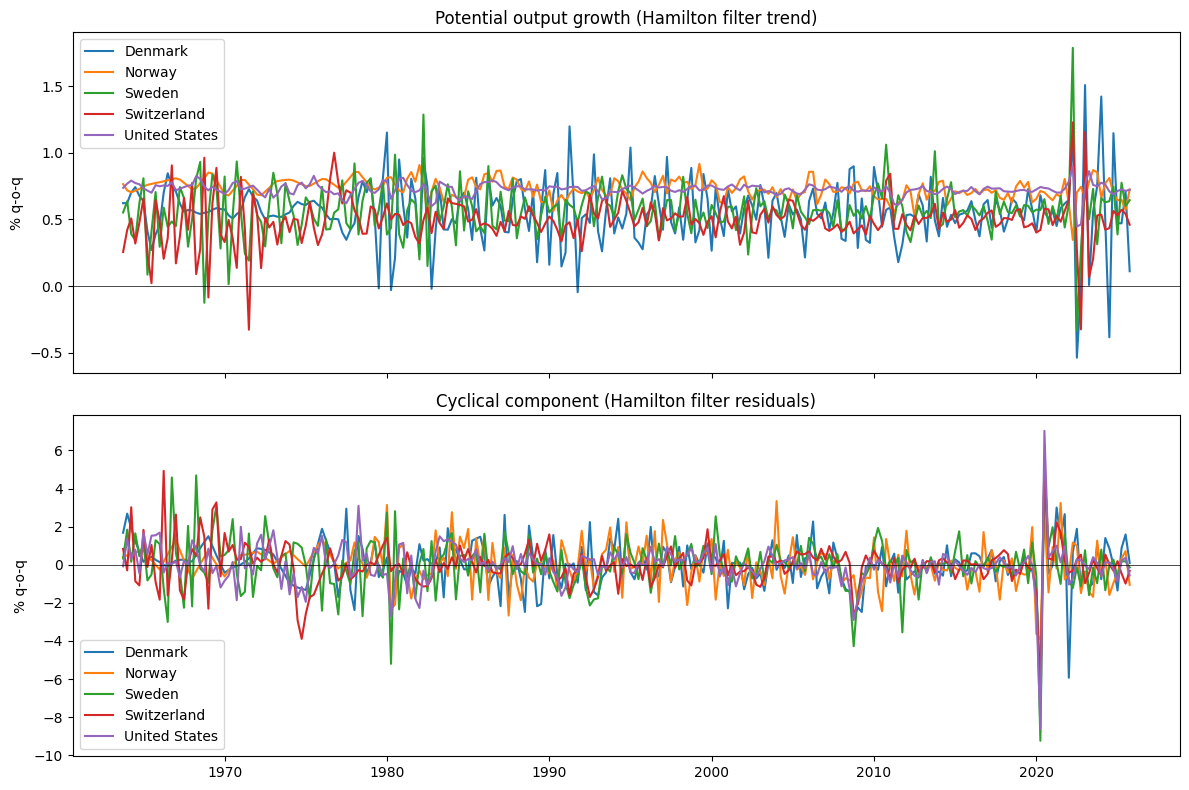

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for country in wide.columns:
    trend, cycle = hamilton_filter(wide[country], h=8, p=4)
    axes[0].plot(trend.index, trend, label=country)
    axes[1].plot(cycle.index, cycle, label=country)

axes[0].set_title('Potential output growth (Hamilton filter trend)')
axes[0].set_ylabel('% q-o-q')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)

axes[1].set_title('Cyclical component (Hamilton filter residuals)')
axes[1].set_ylabel('% q-o-q')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

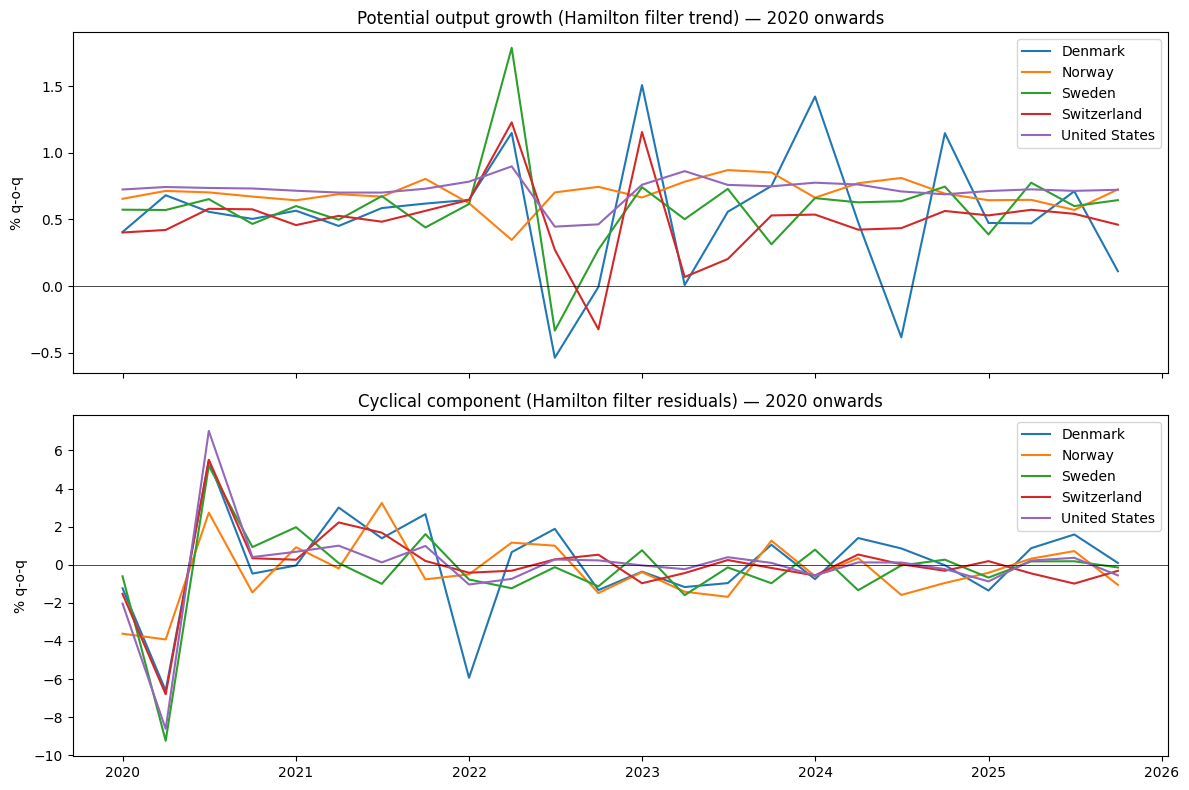

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for country in wide.columns:
    trend, cycle = hamilton_filter(wide[country], h=8, p=4)
    axes[0].plot(trend.loc['2020':].index, trend.loc['2020':], label=country)
    axes[1].plot(cycle.loc['2020':].index, cycle.loc['2020':], label=country)

axes[0].set_title('Potential output growth (Hamilton filter trend) — 2020 onwards')
axes[0].set_ylabel('% q-o-q')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)

axes[1].set_title('Cyclical component (Hamilton filter residuals) — 2020 onwards')
axes[1].set_ylabel('% q-o-q')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# task 2

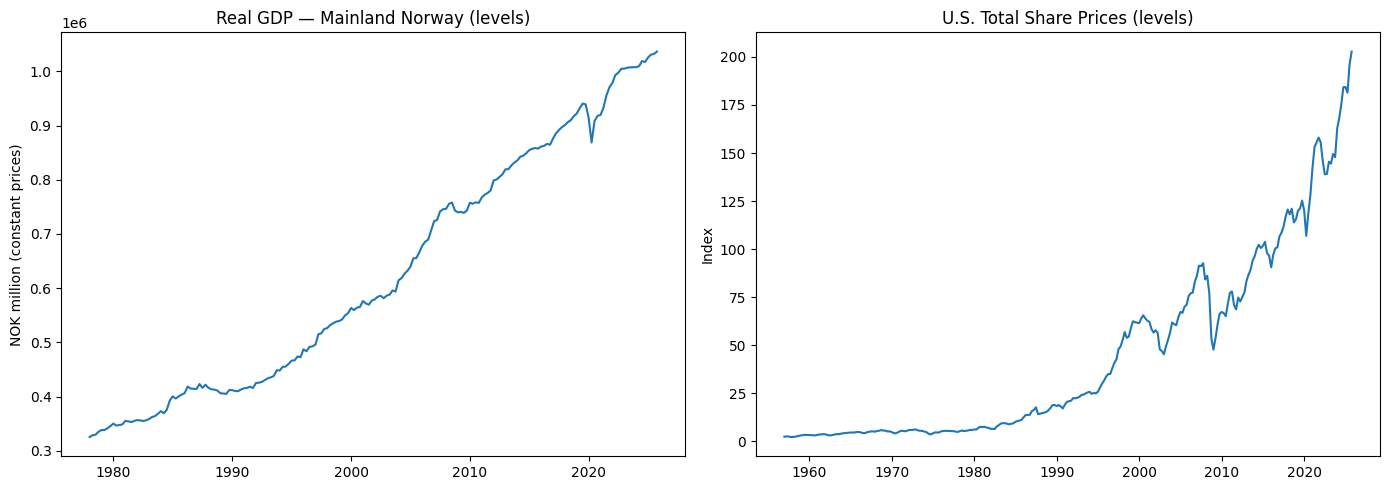

In [6]:
# Load Norway mainland GDP
nor = pd.read_csv('nor-data.csv', sep=';')
nor['date'] = nor['quarter'].str.replace('K', 'Q')
nor['date'] = pd.PeriodIndex(nor['date'], freq='Q').to_timestamp()
nor = nor.set_index('date')['GDP'].astype(float)

# Load U.S. share prices
us = pd.read_csv('us-share.csv', parse_dates=['observation_date'])
us = us.set_index('observation_date')['SPASTT01USQ661N'].astype(float)
us.index.name = 'date'

# Plot levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nor.index, nor)
axes[0].set_title('Real GDP — Mainland Norway (levels)')
axes[0].set_ylabel('NOK million (constant prices)')

axes[1].plot(us.index, us)
axes[1].set_title('U.S. Total Share Prices (levels)')
axes[1].set_ylabel('Index')

plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{name}:')
    print(f'  ADF statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  Lags used:     {result[2]}')
    for key, val in result[4].items():
        print(f'  Critical {key}: {val:.4f}')
    print()

# Levels (expect: non-stationary)
adf_test(nor, 'Norway mainland GDP — levels')
adf_test(us, 'U.S. share prices — levels')

# Log levels (expect: still non-stationary)
adf_test(np.log(nor), 'Norway mainland GDP — log levels')
adf_test(np.log(us), 'U.S. share prices — log levels')

# Growth rates (expect: stationary)
adf_test(np.log(nor).diff().dropna(), 'Norway mainland GDP — log growth')
adf_test(np.log(us).diff().dropna(), 'U.S. share prices — log growth')

Norway mainland GDP — levels:
  ADF statistic: 1.5281
  p-value:       0.9976
  Lags used:     0
  Critical 1%: -3.4651
  Critical 5%: -2.8768
  Critical 10%: -2.5749

U.S. share prices — levels:
  ADF statistic: 3.2892
  p-value:       1.0000
  Lags used:     15
  Critical 1%: -3.4558
  Critical 5%: -2.8727
  Critical 10%: -2.5727

Norway mainland GDP — log levels:
  ADF statistic: -0.4559
  p-value:       0.9003
  Lags used:     0
  Critical 1%: -3.4651
  Critical 5%: -2.8768
  Critical 10%: -2.5749

U.S. share prices — log levels:
  ADF statistic: -0.2645
  p-value:       0.9304
  Lags used:     2
  Critical 1%: -3.4545
  Critical 5%: -2.8722
  Critical 10%: -2.5724

Norway mainland GDP — log growth:
  ADF statistic: -14.2882
  p-value:       0.0000
  Lags used:     0
  Critical 1%: -3.4652
  Critical 5%: -2.8769
  Critical 10%: -2.5749

U.S. share prices — log growth:
  ADF statistic: -10.9797
  p-value:       0.0000
  Lags used:     1
  Critical 1%: -3.4545
  Critical 5%: -2.8722


# task 3

In [8]:
gdp_df = pd.read_csv('../2/data/09189_20260206-101414.csv', delimiter=';')
gdp_df['Y'] = gdp_df['gpd_ex_gov'] + gdp_df['gdp_gov']
gdp_df['year'] = gdp_df['year'].astype(int)

capital_df = pd.read_csv('../2/data/11189_20260206-101742.csv', delimiter=';')
capital_df['year'] = capital_df['year'].astype(int)

hours_df = pd.read_csv('../2/data/09174_20260319-111153.csv', delimiter=';')

tfp_df = gdp_df[['year', 'Y']].merge(capital_df[['year', 'prices']], on='year')
tfp_df = tfp_df.merge(hours_df[['year', 'million workhours (total)']], on='year')

tfp_df = tfp_df.rename(columns={'prices' : 'K'})
tfp_df = tfp_df.rename(columns={'million workhours (total)' : 'L'})

#solow resid: ln(A) = ln(Y) - alpha*ln(K) - (1 - alpha)ln(L)
alpha = 1/3 #standard capital share
tfp_df['ln_tfp'] = (np.log(tfp_df['Y']) - alpha * np.log(tfp_df['K']) - (1 - alpha) * np.log(tfp_df['L']))

tfp_annual = tfp_df.set_index('year')['ln_tfp']

In [9]:
from scipy.interpolate import CubicSpline

#anchor annual obs at mid-y for interpolation 
annual_dates = pd.to_datetime(tfp_annual.index.map(lambda y: f'{y}-07-01'))

#quarterly target grid 
q_dates = pd.date_range(
    start=f'{tfp_annual.index[0]}-01-01',
    end=f'{tfp_annual.index[-1]}-12-31',
    freq='QS'
)

#fit spline and eval 
cs = CubicSpline(annual_dates.astype(np.int64), tfp_annual.values)
tfp_quarterly = pd.Series(cs(q_dates.astype(np.int64)), index=q_dates, name='TFP')

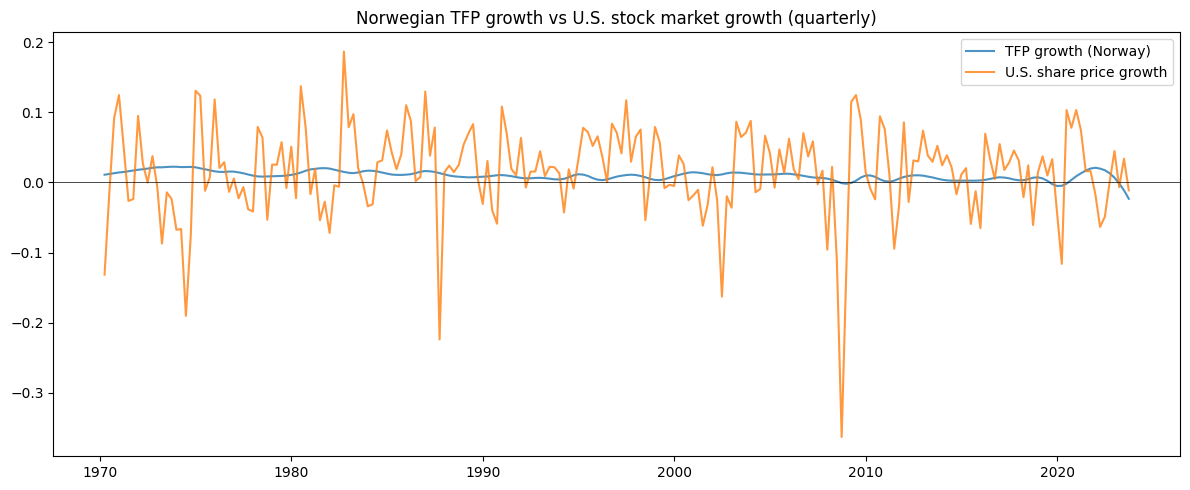

Correlation: -0.0049


In [10]:
#trim to common sample 
common = tfp_quarterly.index.intersection(us.index)
tfp_q = tfp_quarterly.loc[common]
us_q = us.loc[common]

#log growth rates 
tfp_growth = tfp_q.diff().dropna()
us_growth = np.log(us_q).diff().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tfp_growth.index, tfp_growth, label='TFP growth (Norway)', alpha=0.8)
ax.plot(us_growth.index, us_growth, label='U.S. share price growth', alpha=0.8)
ax.legend()
ax.set_title('Norwegian TFP growth vs U.S. stock market growth (quarterly)')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'Correlation: {tfp_growth.corr(us_growth):.4f}')

# task 4

In [11]:
from statsmodels.tsa.api import VAR

#build stationary series 
gdp_growth = np.log(nor).diff().dropna()
gdp_growth.name = 'GDP_growth' 

tfp_growth = tfp_quarterly.diff().dropna()
tfp_growth.name = 'TFP_growth'

us_growth = np.log(us).diff().dropna()
us_growth.name = 'US_stocks_growth'

#combine into one df, trim to common sample 
var_data = pd.DataFrame({
    'GDP_growth' : gdp_growth,
    'TFP_growth' : tfp_growth,
    'US_stocks_growth' : us_growth
}).dropna()

print(f'sample: {var_data.index[0]} to {var_data.index[-1]}\nObservations: {len(var_data)}')
var_data.head()

sample: 1978-04-01 00:00:00 to 2023-10-01 00:00:00
Observations: 183


,GDP_growth,TFP_growth,US_stocks_growth
1978-04-01,0.009874,0.008680,0.079268
1978-07-01,0.003130,0.008402,0.063999
1978-10-01,0.016082,0.008601,-0.053184
1979-01-01,0.009554,0.008843,0.025535
1979-04-01,0.000230,0.008927,0.025325


In [12]:
model = VAR(var_data)
lag_selection = model.select_order(maxlags=12)
lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,-24.88,-24.82,1.569e-11,-24.86
1,-26.94,-26.71,2.005e-12,-26.85
2,-28.64,-28.26,3.633e-13,-28.49
3,-29.30,-28.74*,1.893e-13,-29.07*
4,-29.31*,-28.59,1.869e-13*,-29.02
5,-29.28,-28.40,1.927e-13,-28.92
6,-29.25,-28.20,1.989e-13,-28.82
7,-29.22,-28.01,2.047e-13,-28.73
8,-29.22,-27.84,2.056e-13,-28.66
9,-29.18,-27.64,2.137e-13,-28.56


In [13]:
#use the lag len selected by bic
best_lag = lag_selection.selected_orders['bic']
print(best_lag)

var_result = model.fit(best_lag)
var_result.summary()

3


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 19, Mar, 2026
Time:                     13:41:36
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -28.8147
Nobs:                     180.000    HQIC:                  -29.1311
Log likelihood:           1904.99    FPE:                1.79877e-13
AIC:                     -29.3468    Det(Omega_mle):     1.52944e-13
--------------------------------------------------------------------
Results for equation GDP_growth
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.004491         0.001939            2.317           0.021
L1.GDP_growth              -0.144445         0.077608           -1.861           0.063
L1.TFP_growth               1.2

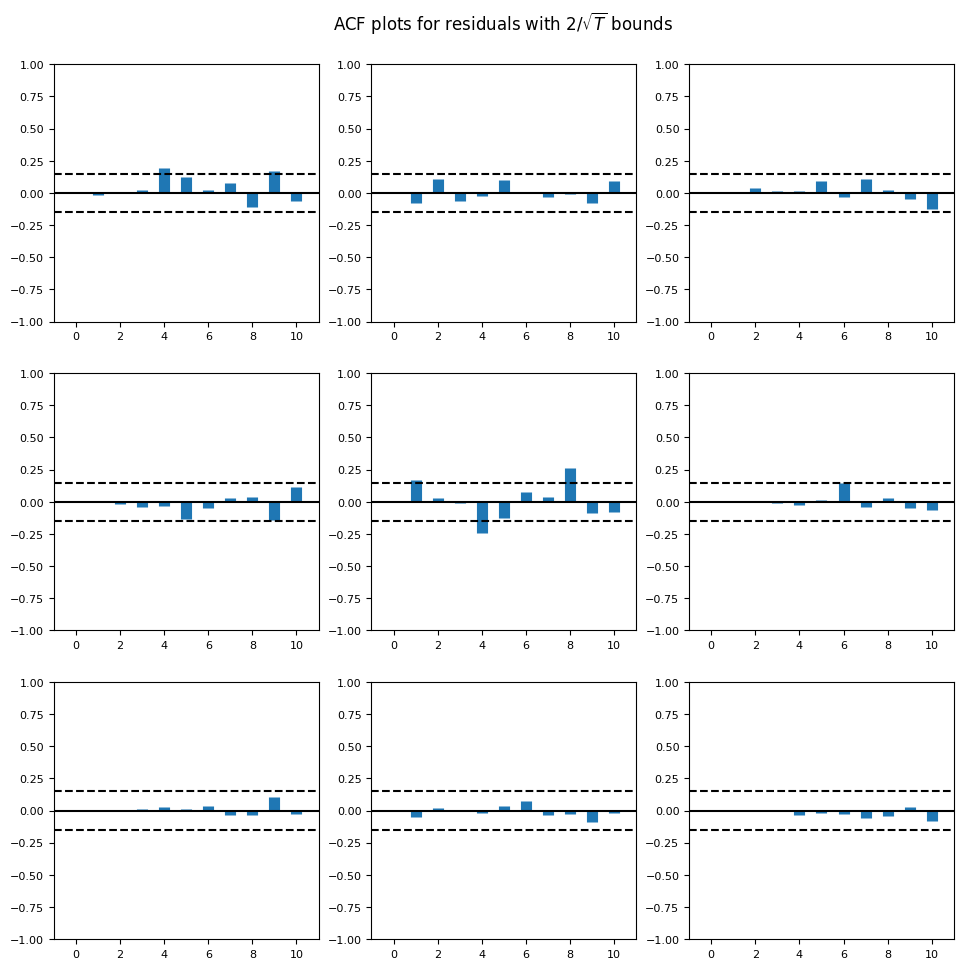

eigenvalues of companion matrix:
[ 4.98554192-0.j         -0.89029301+2.12243735j -0.89029301-2.12243735j
 -2.19081176-0.j          1.33745297+1.34702616j  1.33745297-1.34702616j
  0.95837075+0.47223163j  0.95837075-0.47223163j  1.04583328-0.j        ]
is stable: True


In [14]:
var_result.plot_acorr()
plt.show()

print(f'eigenvalues of companion matrix:\n{var_result.roots}')

is_stable = var_result.is_stable()
print(f'is stable: {is_stable}')

In [15]:
for col in var_data.columns:
    print(f'granger causality tests for {col} equation')
    for other in var_data.columns:
        if other != col:
            result = var_result.test_causality(col, [other])
            print(f'  {other} -> {col}: '
                  f'F={result.test_statistic:.4f}, p={result.pvalue:.4f}')

granger causality tests for GDP_growth equation
  TFP_growth -> GDP_growth: F=3.1141, p=0.0259
  US_stocks_growth -> GDP_growth: F=3.6208, p=0.0131
granger causality tests for TFP_growth equation
  GDP_growth -> TFP_growth: F=0.1497, p=0.9299
  US_stocks_growth -> TFP_growth: F=0.1413, p=0.9352
granger causality tests for US_stocks_growth equation
  GDP_growth -> US_stocks_growth: F=1.9114, p=0.1267
  TFP_growth -> US_stocks_growth: F=0.6876, p=0.5599


# task 5

training samples: 179
test samples: 4


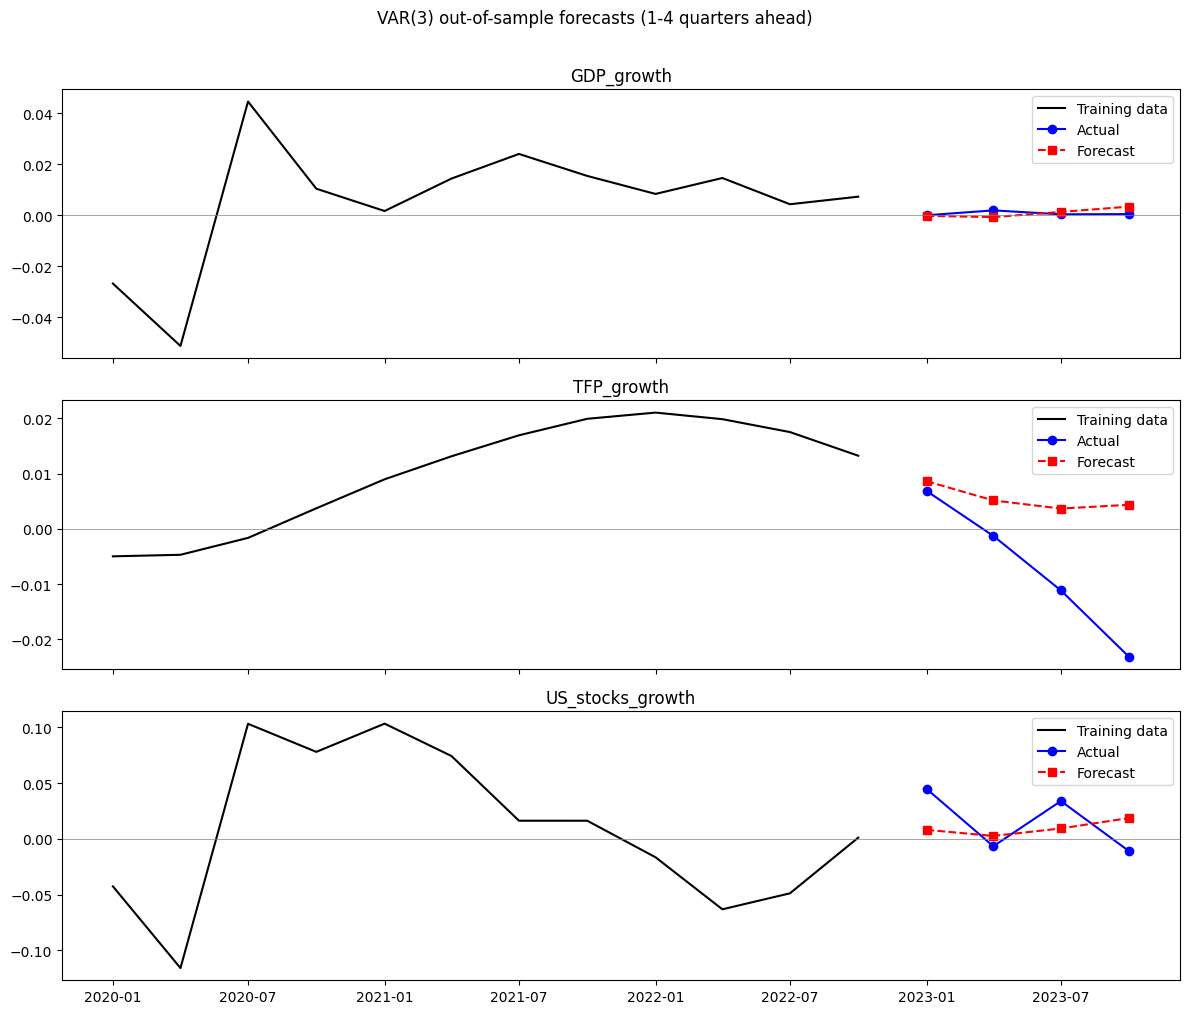


forecast errors (actual - forecast):
            GDP_growth  TFP_growth  US_stocks_growth
2023-01-01    0.000226   -0.001765          0.036793
2023-04-01    0.002631   -0.006412         -0.009247
2023-07-01   -0.000928   -0.014806          0.024592
2023-10-01   -0.002935   -0.027524         -0.029846

RMSE per variable:
GDP_growth          0.002028
TFP_growth          0.015977
US_stocks_growth    0.027087
dtype: float64


In [16]:
train = var_data.iloc[:-4]
test = var_data.iloc[-4:]

print(f'training samples: {len(train)}\ntest samples: {len(test)}')

model_trunc = VAR(train)
var_trunc = model_trunc.fit(3)

#forecast 4 steps ahead
forecast = var_trunc.forecast(train.values[-3:], steps=4)
forecast_df = pd.DataFrame(forecast, index=test.index, columns=var_data.columns)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(var_data.columns):
    axes[i].plot(train.index[-12:], train[col].iloc[-12:], 
                 color='black', label='Training data')
    axes[i].plot(test.index, test[col], 
                 color='blue', marker='o', label='Actual')
    axes[i].plot(forecast_df.index, forecast_df[col], 
                 color='red', marker='s', linestyle='--', label='Forecast')
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].axhline(0, color='grey', linewidth=0.5)

plt.suptitle('VAR(3) out-of-sample forecasts (1-4 quarters ahead)', y=1.01)
plt.tight_layout()
plt.show()

# Print forecast errors
print('\nforecast errors (actual - forecast):')
errors = test - forecast_df
print(errors.round(6))

print('\nRMSE per variable:')
rmse = np.sqrt((errors**2).mean())
print(rmse.round(6))